In [4]:
!pip install triton

In [8]:
from numpy import dtype
import torch
import triton
import triton.language as tl

DEVICE = torch.device(f'cuda:{torch.cuda.current_device()}')

#ptr = pointers in memory where the first

@triton.jit
def add_kernel(
    x_ptr,  #ptr = pointers in memory to the first entry in tensor 'x'. Doesnt actually get the original x,y and output
    y_ptr,
    output_ptr,
    n_elements,
    BLOCK_SIZE: tl.constexpr      # tells triton this is a compile time argument, its static, 
    #the block size gets embedded into the low level GPU kernels, so whenever we instantiate with a different block size(ex:-2048), it creates a completely new kernel
    ):
    PID = tl.program_id(axis = 0) # returns the id of the current program
    # ex:- vec of length 256, BLOCK_SIZE = 64
    # therefore, pID 0 =[0:64], pID 1 =[64:128], pID 2 =[128:192], pID 3 =[192:256]

    block_start = PID * BLOCK_SIZE
    offsets = block_start + tl.arange(0, BLOCK_SIZE)
    mask = offsets < n_elements

    # mask logic --> for ex:- if we have 4097 elements with block size = 1024, there will be 5 blocks. The 5th block will load the 1 element, along with random values for the remaining 1023 elements(because triton doesnt have the concept of padding) 
    # To avoid this, we use a mask. The mask will be True for the elements that are within the bounds of the tensor, and False for the elements that are out of bounds.
    # This ensures that we only load the elements that are within the bounds of the tensor.
    # other = None --> if the mask is False, the element will be set to None

    # load data from HBM/VRAM/DRAM to SRAM/on chip memory
    x = tl.load(x_ptr + offsets, mask=mask, other=None)
    y = tl.load(y_ptr + offsets, mask=mask, other=None)
    

    # perform the operation
    output = x + y

    # write data from SRAM/on chip memory to HBM/VRAM/DRAM
    tl.store(output_ptr + offsets, output, mask=mask)
    

def add(x,y):
    # pre allocating the output:
    output = torch.empty_like(x)

    # check if tensors are on same device:
    assert x.device == DEVICE and y.device == DEVICE
    
    # defining the launch grid:
    n_elements = output.numel()
    grid = lambda meta : (triton.cdiv(n_elements,meta['BLOCK_SIZE']), ) #(4,)
    # cdiv(m,n) = (mon(n-1))//n ---> makes sure that even the non divisible n_elements get divided equally

    add_kernel[grid](
        x,
        y,
        output,
        n_elements,
        BLOCK_SIZE = 1024
    )

    return output



def test_add_kernel(size, atol=1e-3, rtol=1e-3, device = DEVICE):
    # Create test data:
    torch.manual_seed(0)
    x = torch.randn(size, device = device)
    y = torch.randn(size, device = device)
    #run triton kernel and pytorch equivalent
    X_tri = add(x,y)
    X_ref = x + y
    #Compare
    torch.testing.assert_close(X_tri, X_ref, atol = atol, rtol = rtol)
    print("passed")


@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names = ['size'],
        x_vals = [2**i for i in range(12, 24, 1)],
        x_log = True,
        line_arg = 'provider',
        line_vals = ['triton', 'torch'],
        line_names = ['Triton', 'PyTorch'],
        styles = [('blue', '-'), ('green', '-')],
        ylabel = 'GB/s',                             # GB/s because vector add doesnt have any compute, it just reads and writes
        plot_name = 'add-kernel-performance',
        args = {}
    )
)
def benchmark(size, provider):
    #create input data
    x = torch.randn(size, device = DEVICE, dtype = torch.float32)
    y = torch.randn(size, device = DEVICE, dtype = torch.float32)

    quantiles = [0.5, 0.05, 0.95]

    if provider == 'torch':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: x + y, quantiles=quantiles)
    if provider == 'triton':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: add(x,y), quantiles=quantiles)

    gbps = lambda ms: 3 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)

    return gbps(ms), gbps(max_ms), gbps(min_ms)


if __name__ == "__main__":
    test_add_kernel(10000)

    import sys
    if len(sys.argv) > 1 and sys.argv[1] == "--benchmark":
        benchmark.run(save_path = ".", print_data = True)


passed


add-kernel-performance:
         size  Triton (GB/s)  PyTorch (GB/s)
0      4096.0       7.279621        8.000000
1      8192.0      15.437186       22.925373
2     16384.0      40.688742       38.280374
3     32768.0      64.673682       64.167101
4     65536.0      99.902435       99.296973
5    131072.0     144.777616      142.469562
6    262144.0     184.781963      183.061448
7    524288.0     207.392405      204.800005
8   1048576.0     219.980980      219.551087
9   2097152.0     228.613961      228.282153
10  4194304.0     233.431876      233.466534
11  8388608.0     235.282576      235.177028


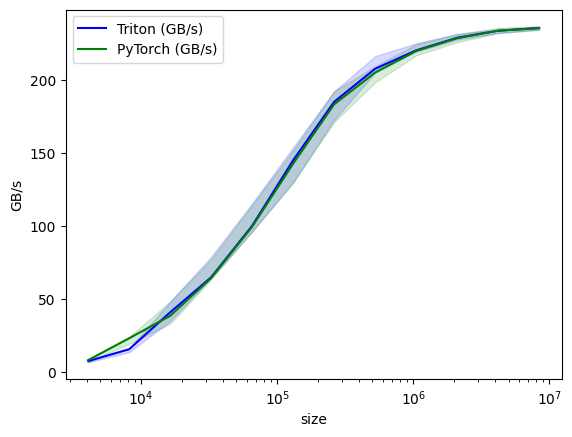

In [9]:
benchmark.run(save_path=".", print_data=True)